# Auto Insurance Pure Premium Modeling

This notebook develops a transparent personal-auto pure-premium indication from public French motor third-party liability data.

The workflow models two components:

1. **Paid-claim frequency** — matched positive payments per policy-year.
2. **Positive-payment severity** — average amount of a matched positive payment.

Their product is annual pure premium:

**Pure premium = paid-claim frequency × positive-payment severity.**

The analysis compares intercept-only benchmarks with pre-specified rating GLMs on one holdout sample. The same holdout supports model comparison and performance reporting, so it is not an untouched final test. The result is expected loss cost, not a quoted customer premium.

## Table of Contents

0. [Setup](#0-setup)
1. [Load and Validate the Data](#1-load-and-validate-the-data)
2. [Build the Modeling Data](#2-build-the-modeling-data)
3. [Initial Data Overview](#3-initial-data-overview)
4. [Rating Features and Train/Holdout Split](#4-rating-features-and-trainholdout-split)
5. [Training-Sample Rating Patterns](#5-training-sample-rating-patterns)
6. [Frequency Models](#6-frequency-models)
7. [Severity Models](#7-severity-models)
8. [Pure Premium Indication](#8-pure-premium-indication)
9. [Holdout Risk Deciles](#9-holdout-risk-deciles)
10. [Holdout Segment Review](#10-holdout-segment-review)
11. [Example Policy and Actuarial Conclusion](#11-example-policy-and-actuarial-conclusion)
12. [Limitations](#12-limitations)

## 0. Setup

Use relative project paths so the notebook can run from the Integration directory or one of its subdirectories.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_gamma_deviance, mean_poisson_deviance
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PLOT_COLORS = {
    "navy": "#16324F",
    "blue": "#2F6690",
    "teal": "#3A7D78",
    "orange": "#D97706",
    "gray": "#94A3B8",
}
PROJECT_DIR = Path.cwd().resolve()

def find_data_dir(start=PROJECT_DIR):
    """Locate the data from the current project path."""
    for candidate in [start, *start.rglob("*")]:
        if (
            (candidate / "fremtpl2freq.csv").exists()
            and (candidate / "fremtpl2sev.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Run the notebook from the directory that contains the data, or specify the path manually."
    )

DATA_DIR = find_data_dir()
FREQ_PATH = DATA_DIR / "fremtpl2freq.csv"
SEV_PATH = DATA_DIR / "fremtpl2sev.csv"

print("Project data located successfully.")
print("Base auto-pricing workflow ready.")

Project data located successfully.
Base auto-pricing workflow ready.


## 1. Load and Validate the Data

The frequency file has one row per policy. The severity file has one row per positive payment. Reported claim counts remain available for context, but the modeled frequency target will count matched positive-payment rows so that frequency and severity use the same loss definition.

In [2]:
freq = pd.read_csv(FREQ_PATH)
sev = pd.read_csv(SEV_PATH)

required_freq = {
    "IDpol", "ClaimNb", "Exposure", "Area", "VehPower", "VehAge",
    "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region",
}
required_sev = {"IDpol", "ClaimAmount"}

missing_freq = sorted(required_freq.difference(freq.columns))
missing_sev = sorted(required_sev.difference(sev.columns))
if missing_freq or missing_sev:
    raise ValueError(
        f"Missing required columns. Frequency: {missing_freq}; severity: {missing_sev}"
    )

if not np.allclose(freq["IDpol"], np.round(freq["IDpol"])):
    raise ValueError("Frequency policy IDs must be integer-valued.")

freq["IDpol"] = freq["IDpol"].astype("int64")
sev["IDpol"] = sev["IDpol"].astype("int64")

for column in ["Area", "VehBrand", "VehGas", "Region"]:
    freq[column] = (
        freq[column].astype(str).str.replace("'", "", regex=False).str.strip()
    )

if not freq["IDpol"].is_unique:
    raise ValueError("The frequency file must have one row per policy.")
if freq[list(required_freq)].isna().any().any():
    raise ValueError("The frequency file contains missing required values.")
if sev[list(required_sev)].isna().any().any():
    raise ValueError("The severity file contains missing required values.")
if not np.isfinite(freq["Exposure"]).all() or (freq["Exposure"] <= 0).any():
    raise ValueError("Exposure must be finite and positive.")
if not np.isfinite(sev["ClaimAmount"]).all() or (sev["ClaimAmount"] <= 0).any():
    raise ValueError("Severity rows must contain finite positive payments.")

input_profile = pd.DataFrame({
    "measure": [
        "Policy rows", "Total exposure", "Reported claims",
        "Positive payment rows", "Total positive paid loss",
    ],
    "value": [
        len(freq), freq["Exposure"].sum(), freq["ClaimNb"].sum(),
        len(sev), sev["ClaimAmount"].sum(),
    ],
})
display(input_profile)

,measure,value
0,Policy rows,"678,013.0000"
1,Total exposure,"358,499.4455"
2,Reported claims,"36,102.0000"
3,Positive payment rows,"26,639.0000"
4,Total positive paid loss,"60,697,930.6800"


## 2. Build the Modeling Data

Positive payments are matched to policy rating records. Unmatched payments are quantified and excluded because their rating characteristics and exposure are unavailable. A left join keeps policies with no matched payment, whose paid-claim count and paid loss are then set to zero.

In [3]:
matched_mask = sev["IDpol"].isin(freq["IDpol"])
sev_matched = sev.loc[matched_mask].copy()
sev_unmatched = sev.loc[~matched_mask].copy()

paid_agg = (
    sev_matched.groupby("IDpol", as_index=False)
    .agg(
        PaidClaimNb=("ClaimAmount", "size"),
        TotalClaimAmount=("ClaimAmount", "sum"),
        MeanPositivePayment=("ClaimAmount", "mean"),
    )
)

df = freq.merge(paid_agg, on="IDpol", how="left", validate="one_to_one")
df["PaidClaimNb"] = df["PaidClaimNb"].fillna(0).astype("int64")
df["TotalClaimAmount"] = df["TotalClaimAmount"].fillna(0.0)
df["MeanPositivePayment"] = df["MeanPositivePayment"].fillna(0.0)

reconciliation = pd.DataFrame({
    "measure": [
        "Policy rows",
        "Reported claims",
        "Matched positive payments",
        "Unmatched positive payments",
        "Matched paid loss",
        "Unmatched paid loss",
    ],
    "value": [
        len(df),
        df["ClaimNb"].sum(),
        len(sev_matched),
        len(sev_unmatched),
        sev_matched["ClaimAmount"].sum(),
        sev_unmatched["ClaimAmount"].sum(),
    ],
})

data_checks = pd.DataFrame({
    "check": [
        "Unique policy IDs",
        "Positive exposure",
        "Nonnegative paid-claim counts",
        "Nonnegative policy paid loss",
        "Matched payment count reconciles",
        "Matched paid loss reconciles",
    ],
    "passed": [
        df["IDpol"].is_unique,
        bool((df["Exposure"] > 0).all()),
        bool((df["PaidClaimNb"] >= 0).all()),
        bool((df["TotalClaimAmount"] >= 0).all()),
        int(df["PaidClaimNb"].sum()) == len(sev_matched),
        bool(np.isclose(df["TotalClaimAmount"].sum(), sev_matched["ClaimAmount"].sum())),
    ],
})

if not data_checks["passed"].all():
    raise ValueError("One or more modeling-data checks failed.")

display(reconciliation)
display(data_checks)

,measure,value
0,Policy rows,"678,013.0000"
1,Reported claims,"36,102.0000"
2,Matched positive payments,"26,444.0000"
3,Unmatched positive payments,195.0000
4,Matched paid loss,"59,909,216.5000"
5,Unmatched paid loss,"788,714.1800"


,check,passed
0,Unique policy IDs,True
1,Positive exposure,True
2,Nonnegative paid-claim counts,True
3,Nonnegative policy paid loss,True
4,Matched payment count reconciles,True
5,Matched paid loss reconciles,True


## 3. Initial Data Overview

Claim frequency is sparse and payment severity is strongly right-skewed. These plots describe the modeling targets before any model is fitted. The large-loss statistics are descriptive; the primary Gamma model uses all matched positive payments without capping.

,PaidClaimNb,policies,label,policy_share
0,0,653069,0,0.9632
1,1,23571,1,0.0348
2,2,1298,2,0.0019
3,3,62,3,0.0001
4,4,13,4+,0.0000


,quantile,ClaimAmount
0,0.5000,"1,172.0000"
1,0.7500,"1,212.3850"
2,0.9000,"2,767.6040"
3,0.9500,"4,765.0935"
4,0.9900,"16,451.2240"
5,0.9950,"34,376.9643"
6,1.0000,"4,075,400.5600"


99th percentile payment: 16,451.22
Share of matched loss at or above the 99th percentile: 38.0%


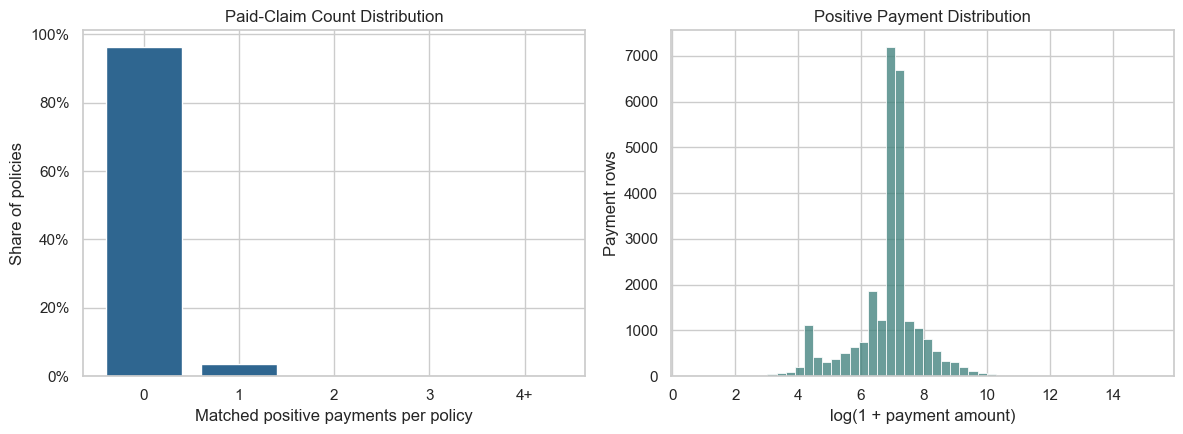

In [4]:
claim_count_distribution = (
    df["PaidClaimNb"].clip(upper=4).value_counts().sort_index().rename_axis("PaidClaimNb")
    .reset_index(name="policies")
)
claim_count_distribution["label"] = (
    claim_count_distribution["PaidClaimNb"].astype(int).astype(str).replace({"4": "4+"})
)
claim_count_distribution["policy_share"] = (
    claim_count_distribution["policies"] / len(df)
)

severity_quantiles = (
    sev_matched["ClaimAmount"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 1.00])
    .rename("ClaimAmount")
    .rename_axis("quantile")
    .reset_index()
)
large_loss_threshold = sev_matched["ClaimAmount"].quantile(0.99)
top_one_percent_share = (
    sev_matched.loc[
        sev_matched["ClaimAmount"] >= large_loss_threshold, "ClaimAmount"
    ].sum()
    / sev_matched["ClaimAmount"].sum()
)

display(claim_count_distribution)
display(severity_quantiles)
print(f"99th percentile payment: {large_loss_threshold:,.2f}")
print(f"Share of matched loss at or above the 99th percentile: {top_one_percent_share:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(
    claim_count_distribution["label"],
    claim_count_distribution["policy_share"],
    color=PLOT_COLORS["blue"],
)
axes[0].set(
    title="Paid-Claim Count Distribution",
    xlabel="Matched positive payments per policy",
    ylabel="Share of policies",
)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

sns.histplot(
    np.log1p(sev_matched["ClaimAmount"]),
    bins=50,
    color=PLOT_COLORS["teal"],
    ax=axes[1],
)
axes[1].set(
    title="Positive Payment Distribution",
    xlabel="log(1 + payment amount)",
    ylabel="Payment rows",
)
plt.tight_layout()
plt.show()

## 4. Rating Features and Train/Holdout Split

The feature set is intentionally compact and interpretable. Fixed bands reduce the influence of extreme values without learning cutoffs from the holdout set. Policies are split 80%/20%; severity rows inherit the split of their policy ID.

In [5]:
def add_rating_features(frame):
    """Create the same simple rating features for training and prediction."""
    out = frame.copy()
    out["VehPower"] = pd.Categorical(out["VehPower"].astype(int))
    out["Area"] = pd.Categorical(out["Area"].astype(str))
    out["VehGas"] = pd.Categorical(out["VehGas"].astype(str))
    out["VehAgeBand"] = pd.cut(
        out["VehAge"],
        bins=[-np.inf, 1, 5, 10, 20, np.inf],
        labels=["0-1", "2-5", "6-10", "11-20", "21+"],
    )
    out["DrivAgeBand"] = pd.cut(
        out["DrivAge"],
        bins=[17, 24, 34, 49, 64, np.inf],
        labels=["18-24", "25-34", "35-49", "50-64", "65+"],
        include_lowest=True,
    )
    out["BonusMalusBand"] = pd.cut(
        out["BonusMalus"],
        bins=[-np.inf, 50, 75, 100, 125, np.inf],
        labels=["50", "51-75", "76-100", "101-125", "126+"],
    )
    out["LogDensity"] = np.log1p(out["Density"].astype(float))
    return out

df = add_rating_features(df)

model_feature_columns = [
    "IDpol", "Area", "VehPower", "VehAgeBand", "DrivAgeBand",
    "BonusMalusBand", "VehGas", "LogDensity",
]
sev_model = sev_matched.merge(
    df[model_feature_columns],
    on="IDpol",
    how="inner",
    validate="many_to_one",
)

train_ids, holdout_ids = train_test_split(
    df["IDpol"].to_numpy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_id_set = set(train_ids.tolist())
holdout_id_set = set(holdout_ids.tolist())

if train_id_set.intersection(holdout_id_set):
    raise ValueError("Train and holdout policy IDs must be disjoint.")

df["Split"] = np.where(df["IDpol"].isin(train_id_set), "train", "holdout")
sev_model["Split"] = np.where(
    sev_model["IDpol"].isin(train_id_set), "train", "holdout"
)

train = df.loc[df["Split"] == "train"].copy()
holdout = df.loc[df["Split"] == "holdout"].copy()
sev_train = sev_model.loc[sev_model["Split"] == "train"].copy()
sev_holdout = sev_model.loc[sev_model["Split"] == "holdout"].copy()

split_summary = (
    df.groupby("Split", as_index=False)
    .agg(
        policies=("IDpol", "size"),
        exposure=("Exposure", "sum"),
        paid_claims=("PaidClaimNb", "sum"),
        paid_loss=("TotalClaimAmount", "sum"),
    )
)
split_summary["paid_frequency"] = (
    split_summary["paid_claims"] / split_summary["exposure"]
)
split_summary["pure_premium"] = (
    split_summary["paid_loss"] / split_summary["exposure"]
)

display(split_summary)
print(f"Training payment rows: {len(sev_train):,}")
print(f"Holdout payment rows: {len(sev_holdout):,}")

,Split,policies,exposure,paid_claims,paid_loss,paid_frequency,pure_premium
0,holdout,135603,"71,624.4231",5400,"11,868,103.8400",0.0754,165.6991
1,train,542410,"286,875.0224",21044,"48,041,112.6600",0.0734,167.4636


Training payment rows: 21,044
Holdout payment rows: 5,400


## 5. Training-Sample Rating Patterns

Observed patterns are reviewed on training data only. They support business interpretation but do not prove causality and are not credibility-adjusted rating indications.

,DrivAgeBand,policies,exposure,paid_claims,paid_loss,paid_frequency,average_severity,pure_premium
0,18-24,24158,"10,016.2531",1601,"10,769,280.0300",0.1598,"6,726.5959","1,075.1805"
1,25-34,112662,"51,680.2878",3933,"7,972,448.1900",0.0761,"2,027.0654",154.2648
2,35-49,201931,"105,173.3257",7661,"13,550,211.1500",0.0728,"1,768.7262",128.8370
3,50-64,145117,"81,609.3547",5557,"10,687,591.0100",0.0681,"1,923.2663",130.9604
4,65+,58542,"38,395.8010",2292,"5,061,582.2800",0.0597,"2,208.3692",131.8265


,Area,policies,exposure,paid_claims,paid_loss,paid_frequency,average_severity,pure_premium
0,A,83205,"49,608.1744",2665,"6,086,798.6200",0.0537,"2,283.9770",122.6975
1,B,60397,"34,440.2239",2100,"7,998,582.1200",0.0610,"3,808.8486",232.2454
2,C,153725,"83,741.5423",5663,"11,793,714.4700",0.0676,"2,082.5913",140.8347
3,D,121037,"61,595.1918",5114,"12,028,431.7000",0.0830,"2,352.0594",195.2820
4,E,109733,"51,020.2897",4886,"9,327,260.7400",0.0958,"1,908.9768",182.8147
5,F,14313,"6,469.6004",616,"806,325.0100",0.0952,"1,308.9692",124.6329


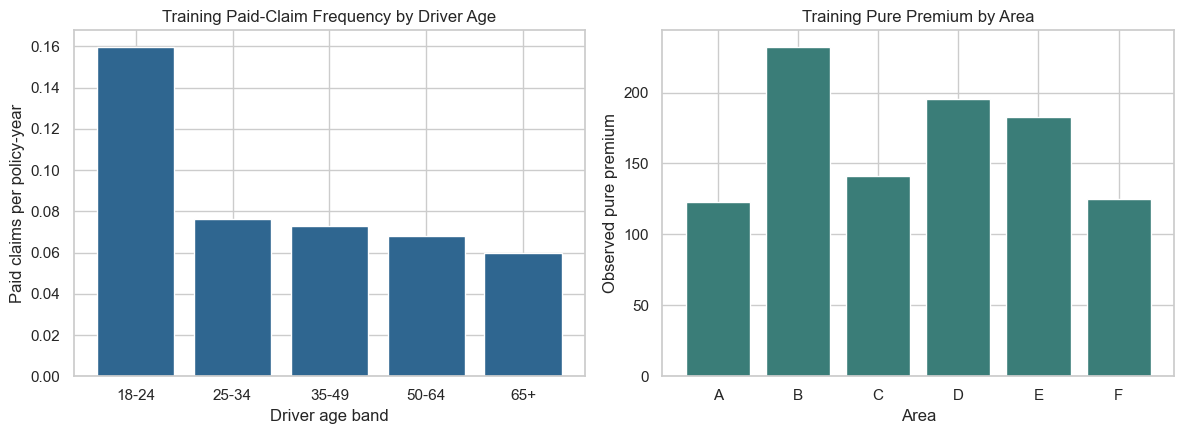

In [6]:
def observed_rating_summary(data, group_column):
    summary = (
        data.groupby(group_column, observed=True, as_index=False)
        .agg(
            policies=("IDpol", "size"),
            exposure=("Exposure", "sum"),
            paid_claims=("PaidClaimNb", "sum"),
            paid_loss=("TotalClaimAmount", "sum"),
        )
    )
    summary["paid_frequency"] = summary["paid_claims"] / summary["exposure"]
    summary["average_severity"] = (
        summary["paid_loss"] / summary["paid_claims"].replace(0, np.nan)
    )
    summary["pure_premium"] = summary["paid_loss"] / summary["exposure"]
    return summary

training_age_summary = observed_rating_summary(train, "DrivAgeBand")
training_area_summary = observed_rating_summary(train, "Area")

display(training_age_summary)
display(training_area_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(
    training_age_summary["DrivAgeBand"].astype(str),
    training_age_summary["paid_frequency"],
    color=PLOT_COLORS["blue"],
)
axes[0].set(
    title="Training Paid-Claim Frequency by Driver Age",
    xlabel="Driver age band",
    ylabel="Paid claims per policy-year",
)

axes[1].bar(
    training_area_summary["Area"].astype(str),
    training_area_summary["pure_premium"],
    color=PLOT_COLORS["teal"],
)
axes[1].set(
    title="Training Pure Premium by Area",
    xlabel="Area",
    ylabel="Observed pure premium",
)
plt.tight_layout()
plt.show()

## 6. Frequency Models

An intercept-only Poisson model is the benchmark. The rating model adds a compact set of policy characteristics. Both use a log link and log exposure offset, so predictions are expected paid-claim counts for each policy's observed exposure.

The rating formula is specified before reviewing holdout results.

In [7]:
rating_terms = (
    "C(Area) + C(VehPower) + C(VehAgeBand) + C(DrivAgeBand) "
    "+ C(BonusMalusBand) + C(VehGas) + LogDensity"
)
frequency_formula = "PaidClaimNb ~ " + rating_terms

freq_null = smf.glm(
    formula="PaidClaimNb ~ 1",
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"]),
).fit()

freq_glm = smf.glm(
    formula=frequency_formula,
    data=train,
    family=sm.families.Poisson(),
    offset=np.log(train["Exposure"]),
).fit()

def frequency_metrics(data, split_name):
    observed = data["PaidClaimNb"].to_numpy(dtype=float)
    null_prediction = np.maximum(
        freq_null.predict(data, offset=np.log(data["Exposure"])), 1e-12
    )
    rating_prediction = np.maximum(
        freq_glm.predict(data, offset=np.log(data["Exposure"])), 1e-12
    )
    return [
        {
            "split": split_name,
            "model": "Intercept-only",
            "poisson_deviance": mean_poisson_deviance(observed, null_prediction),
            "claim_AE": observed.sum() / null_prediction.sum(),
        },
        {
            "split": split_name,
            "model": "Rating GLM",
            "poisson_deviance": mean_poisson_deviance(observed, rating_prediction),
            "claim_AE": observed.sum() / rating_prediction.sum(),
        },
    ]

freq_metrics = pd.DataFrame(
    frequency_metrics(train, "train") + frequency_metrics(holdout, "holdout")
)
pearson_dispersion = freq_glm.pearson_chi2 / freq_glm.df_resid

freq_relativities = (
    pd.DataFrame({
        "term": freq_glm.params.index,
        "coefficient": freq_glm.params.values,
        "relativity": np.exp(freq_glm.params.values),
    })
    .query("term != 'Intercept'")
    .assign(distance_from_one=lambda x: np.abs(np.log(x["relativity"])))
    .sort_values("distance_from_one", ascending=False)
    .drop(columns="distance_from_one")
    .head(12)
)

display(freq_metrics)
print(f"Frequency Pearson dispersion: {pearson_dispersion:.3f}")
display(freq_relativities)

,split,model,poisson_deviance,claim_AE
0,train,Intercept-only,0.2526,1.0000
1,train,Rating GLM,0.2421,1.0000
2,holdout,Intercept-only,0.2566,1.0278
3,holdout,Rating GLM,0.2461,1.0288


Frequency Pearson dispersion: 1.869


,term,coefficient,relativity
28,C(BonusMalusBand)[T.126+],2.2245,9.2487
27,C(BonusMalusBand)[T.101-125],1.9659,7.1415
26,C(BonusMalusBand)[T.76-100],1.0163,2.7629
25,C(BonusMalusBand)[T.51-75],0.6719,1.9580
21,C(DrivAgeBand)[T.25-34],-0.4372,0.6458
20,C(VehAgeBand)[T.21+],-0.3762,0.6865
12,C(VehPower)[T.11],0.2992,1.3488
14,C(VehPower)[T.13],0.2982,1.3474
13,C(VehPower)[T.12],0.2195,1.2454
15,C(VehPower)[T.14],0.2143,1.2389


## 7. Severity Models

Severity is modeled on matched positive-payment rows. The Gamma family reflects positive, right-skewed amounts, and the log link keeps predictions positive. As with frequency, an intercept-only benchmark is compared with the pre-specified rating GLM.

In [8]:
severity_formula = "ClaimAmount ~ " + rating_terms

sev_null = smf.glm(
    formula="ClaimAmount ~ 1",
    data=sev_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

sev_glm = smf.glm(
    formula=severity_formula,
    data=sev_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
).fit()

def severity_metrics(data, split_name):
    observed = data["ClaimAmount"].to_numpy(dtype=float)
    null_prediction = np.maximum(sev_null.predict(data), 1e-12)
    rating_prediction = np.maximum(sev_glm.predict(data), 1e-12)
    return [
        {
            "split": split_name,
            "model": "Intercept-only",
            "gamma_deviance": mean_gamma_deviance(observed, null_prediction),
            "severity_AE": observed.sum() / null_prediction.sum(),
        },
        {
            "split": split_name,
            "model": "Rating GLM",
            "gamma_deviance": mean_gamma_deviance(observed, rating_prediction),
            "severity_AE": observed.sum() / rating_prediction.sum(),
        },
    ]

sev_metrics = pd.DataFrame(
    severity_metrics(sev_train, "train") + severity_metrics(sev_holdout, "holdout")
)

sev_relativities = (
    pd.DataFrame({
        "term": sev_glm.params.index,
        "coefficient": sev_glm.params.values,
        "relativity": np.exp(sev_glm.params.values),
    })
    .query("term != 'Intercept'")
    .assign(distance_from_one=lambda x: np.abs(np.log(x["relativity"])))
    .sort_values("distance_from_one", ascending=False)
    .drop(columns="distance_from_one")
    .head(12)
)

display(sev_metrics)
print(f"Gamma model scale estimate: {sev_glm.scale:.3f}")
display(sev_relativities)

,split,model,gamma_deviance,severity_AE
0,train,Intercept-only,1.7758,1.0000
1,train,Rating GLM,1.5608,1.0349
2,holdout,Intercept-only,1.6879,0.9627
3,holdout,Rating GLM,1.8499,0.9889


Gamma model scale estimate: 25.023


,term,coefficient,relativity
5,C(Area)[T.F],-1.1097,0.3296
22,C(DrivAgeBand)[T.35-49],-0.9792,0.3756
21,C(DrivAgeBand)[T.25-34],-0.9054,0.4044
23,C(DrivAgeBand)[T.50-64],-0.8804,0.4146
24,C(DrivAgeBand)[T.65+],-0.7263,0.4837
4,C(Area)[T.E],-0.6198,0.5381
15,C(VehPower)[T.14],0.6096,1.8397
2,C(Area)[T.C],-0.3857,0.6800
10,C(VehPower)[T.9],0.3730,1.4520
16,C(VehPower)[T.15],-0.3650,0.6942


## 8. Pure Premium Indication

Predicted annual frequency is multiplied by predicted positive-payment severity. Expected loss then adjusts pure premium for each policy's exposure.

Portfolio A/E is a calibration diagnostic:

**A/E = actual paid loss ÷ expected paid loss.**

The lower-deviance frequency and severity components on the holdout are retained. No post-hoc calibration factor is applied.

In [9]:
frequency_holdout_results = (
    freq_metrics.loc[freq_metrics["split"] == "holdout"].set_index("model")
)
severity_holdout_results = (
    sev_metrics.loc[sev_metrics["split"] == "holdout"].set_index("model")
)

selected_frequency_name = frequency_holdout_results["poisson_deviance"].idxmin()
selected_severity_name = severity_holdout_results["gamma_deviance"].idxmin()
selected_frequency_model = (
    freq_glm if selected_frequency_name == "Rating GLM" else freq_null
)
selected_severity_model = (
    sev_glm if selected_severity_name == "Rating GLM" else sev_null
)
selected_combined_name = (
    f"{selected_frequency_name} frequency × "
    f"{selected_severity_name} severity"
)

print(f"Selected frequency component: {selected_frequency_name}")
print(f"Selected severity component: {selected_severity_name}")

def add_pure_premium_predictions(frame):
    out = frame.copy()
    out["baseline_pred_claim_count"] = np.maximum(
        freq_null.predict(out, offset=np.log(out["Exposure"])), 1e-12
    )
    out["selected_pred_claim_count"] = np.maximum(
        selected_frequency_model.predict(
            out, offset=np.log(out["Exposure"])
        ),
        1e-12,
    )
    out["baseline_pred_frequency"] = (
        out["baseline_pred_claim_count"] / out["Exposure"]
    )
    out["selected_pred_frequency"] = (
        out["selected_pred_claim_count"] / out["Exposure"]
    )
    out["baseline_pred_severity"] = np.maximum(
        sev_null.predict(out), 1e-12
    )
    out["selected_pred_severity"] = np.maximum(
        selected_severity_model.predict(out), 1e-12
    )
    for prefix in ["baseline", "selected"]:
        out[f"{prefix}_pred_pure_premium"] = (
            out[f"{prefix}_pred_frequency"]
            * out[f"{prefix}_pred_severity"]
        )
        out[f"{prefix}_expected_loss"] = (
            out[f"{prefix}_pred_pure_premium"] * out["Exposure"]
        )
    return out

train = add_pure_premium_predictions(train)
holdout = add_pure_premium_predictions(holdout)

portfolio_rows = []
for split_name, data in [("train", train), ("holdout", holdout)]:
    actual_loss = data["TotalClaimAmount"].sum()
    exposure = data["Exposure"].sum()
    for prefix, model_name in [
        (
            "baseline",
            "Intercept-only frequency × Intercept-only severity",
        ),
        ("selected", selected_combined_name),
    ]:
        expected_loss = data[f"{prefix}_expected_loss"].sum()
        portfolio_rows.append({
            "split": split_name,
            "model": model_name,
            "exposure": exposure,
            "actual_loss": actual_loss,
            "expected_loss": expected_loss,
            "actual_pure_premium": actual_loss / exposure,
            "expected_pure_premium": expected_loss / exposure,
            "loss_AE": actual_loss / expected_loss,
        })

portfolio_summary = pd.DataFrame(portfolio_rows)
display(portfolio_summary)

Selected frequency component: Rating GLM
Selected severity component: Intercept-only


,split,model,exposure,actual_loss,expected_loss,actual_pure_premium,expected_pure_premium,loss_AE
0,train,Intercept-only frequency × Intercept-only seve...,"286,875.0224","48,041,112.6600","48,041,112.6600",167.4636,167.4636,1.0000
1,train,Rating GLM frequency × Intercept-only severity,"286,875.0224","48,041,112.6600","48,041,112.6600",167.4636,167.4636,1.0000
2,holdout,Intercept-only frequency × Intercept-only seve...,"71,624.4231","11,868,103.8400","11,994,480.9116",165.6991,167.4636,0.9895
3,holdout,Rating GLM frequency × Intercept-only severity,"71,624.4231","11,868,103.8400","11,982,971.1714",165.6991,167.3029,0.9904


## 9. Holdout Risk Deciles

Policies are ranked by predicted rating-GLM pure premium and placed into ten equally sized policy groups. The table compares actual and expected loss cost across the ranking. Deciles assess risk separation; their A/E values assess calibration within each group.

,RiskDecile,policies,exposure,paid_claims,actual_loss,expected_loss,actual_pure_premium,expected_pure_premium,loss_AE
0,1,13561,"8,640.0030",288,"947,526.0800","718,814.8448",109.6673,83.1961,1.3182
1,2,13560,"8,280.7452",357,"711,927.5500","846,362.2216",85.9739,102.2085,0.8412
2,3,13560,"8,016.9742",410,"891,837.5200","909,379.4636",111.2437,113.4318,0.9807
3,4,13560,"7,621.5334",419,"1,178,083.5100","943,216.7829",154.5730,123.7568,1.2490
4,5,13561,"7,525.3967",465,"678,245.5800","1,017,313.9764",90.1276,135.1841,0.6667
5,6,13560,"7,051.0674",473,"722,521.2000","1,061,754.8834",102.4698,150.5807,0.6805
6,7,13560,"6,517.3116",574,"1,053,387.3800","1,150,411.7856",161.6291,176.5163,0.9157
7,8,13560,"6,239.8627",657,"1,231,278.9300","1,366,395.4582",197.3247,218.9785,0.9011
8,9,13560,"6,008.6080",775,"1,361,796.2600","1,614,111.6605",226.6409,268.6332,0.8437
9,10,13561,"5,722.9210",982,"3,091,499.8300","2,355,210.0943",540.1961,411.5399,1.3126


Top-decile actual pure-premium lift versus the holdout portfolio: 3.26x


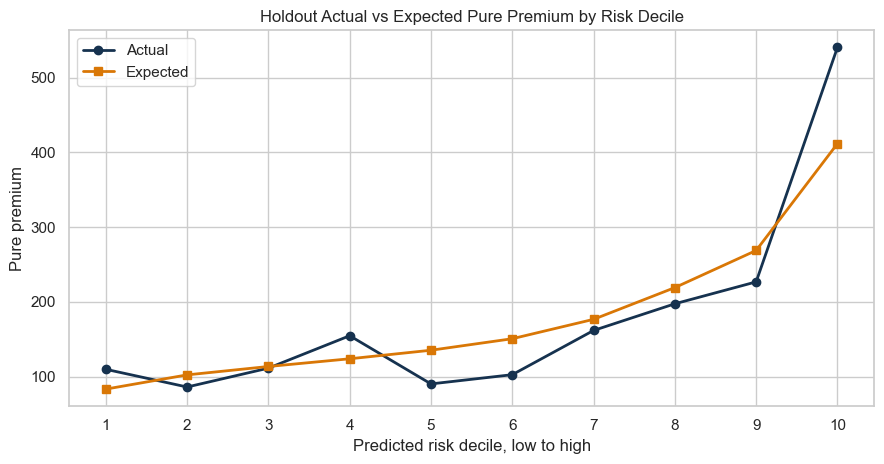

In [10]:
holdout["RiskDecile"] = pd.qcut(
    holdout["selected_pred_pure_premium"].rank(method="first"),
    q=10,
    labels=np.arange(1, 11),
).astype(int)

decile_summary = (
    holdout.groupby("RiskDecile", as_index=False)
    .agg(
        policies=("IDpol", "size"),
        exposure=("Exposure", "sum"),
        paid_claims=("PaidClaimNb", "sum"),
        actual_loss=("TotalClaimAmount", "sum"),
        expected_loss=("selected_expected_loss", "sum"),
    )
)
decile_summary["actual_pure_premium"] = (
    decile_summary["actual_loss"] / decile_summary["exposure"]
)
decile_summary["expected_pure_premium"] = (
    decile_summary["expected_loss"] / decile_summary["exposure"]
)
decile_summary["loss_AE"] = (
    decile_summary["actual_loss"] / decile_summary["expected_loss"]
)

overall_holdout_pure_premium = (
    holdout["TotalClaimAmount"].sum() / holdout["Exposure"].sum()
)
top_decile_lift = (
    decile_summary.loc[
        decile_summary["RiskDecile"] == 10, "actual_pure_premium"
    ].iloc[0]
    / overall_holdout_pure_premium
)

display(decile_summary)
print(
    "Top-decile actual pure-premium lift versus the holdout portfolio: "
    f"{top_decile_lift:.2f}x"
)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(
    decile_summary["RiskDecile"],
    decile_summary["actual_pure_premium"],
    marker="o",
    linewidth=2,
    label="Actual",
    color=PLOT_COLORS["navy"],
)
ax.plot(
    decile_summary["RiskDecile"],
    decile_summary["expected_pure_premium"],
    marker="s",
    linewidth=2,
    label="Expected",
    color=PLOT_COLORS["orange"],
)
ax.set(
    title="Holdout Actual vs Expected Pure Premium by Risk Decile",
    xlabel="Predicted risk decile, low to high",
    ylabel="Pure premium",
    xticks=np.arange(1, 11),
)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Holdout Segment Review

Two interpretable rating dimensions are reviewed on the holdout set. Exposure and claim volume provide context for A/E. Segment differences are predictive diagnostics, not causal effects or final rate relativities.

In [11]:
def segment_summary(data, group_column):
    result = (
        data.groupby(group_column, observed=True, as_index=False)
        .agg(
            policies=("IDpol", "size"),
            exposure=("Exposure", "sum"),
            paid_claims=("PaidClaimNb", "sum"),
            actual_loss=("TotalClaimAmount", "sum"),
            expected_loss=("selected_expected_loss", "sum"),
        )
    )
    result["actual_pure_premium"] = result["actual_loss"] / result["exposure"]
    result["expected_pure_premium"] = (
        result["expected_loss"] / result["exposure"]
    )
    result["loss_AE"] = result["actual_loss"] / result["expected_loss"]
    return result

driver_age_review = segment_summary(holdout, "DrivAgeBand")
bonus_malus_review = segment_summary(holdout, "BonusMalusBand")

display(driver_age_review)
display(bonus_malus_review)

,DrivAgeBand,policies,exposure,paid_claims,actual_loss,expected_loss,actual_pure_premium,expected_pure_premium,loss_AE
0,18-24,6040,"2,472.9080",410,"972,064.1800","888,861.1807",393.0855,359.4397,1.0936
1,25-34,28285,"12,918.3266",1040,"1,984,971.7200","2,241,839.0981",153.6555,173.5394,0.8854
2,35-49,50195,"26,057.1150",1902,"4,715,185.4400","4,333,143.7381",180.9558,166.2941,1.0882
3,50-64,36463,"20,581.3547",1476,"2,598,660.4000","3,205,747.2489",126.2628,155.7598,0.8106
4,65+,14620,"9,594.7188",572,"1,597,222.1000","1,313,379.9055",166.4689,136.8857,1.2161


,BonusMalusBand,policies,exposure,paid_claims,actual_loss,expected_loss,actual_pure_premium,expected_pure_premium,loss_AE
0,50,76776,"45,002.3525",2341,"5,094,238.1600","5,278,070.3786",113.1994,117.2843,0.9652
1,51-75,35018,"16,928.7307",1641,"3,787,559.5900","3,519,519.2587",223.7356,207.9021,1.0762
2,76-100,22300,"9,022.0651",1191,"2,559,326.4700","2,646,852.0173",283.6741,293.3754,0.9669
3,101-125,1350,598.0765,200,"346,544.8300","460,879.6558",579.4323,770.6032,0.7519
4,126+,159,73.1982,27,"80,434.7900","77,649.8610","1,098.8630","1,060.8166",1.0359


## 11. Example Policy and Actuarial Conclusion

A policy near the median predicted risk illustrates how the two GLM components combine. This is a model calculation, not a customer quote.

In [12]:
median_score = holdout["selected_pred_pure_premium"].median()
example_index = (
    holdout["selected_pred_pure_premium"] - median_score
).abs().idxmin()
example = holdout.loc[example_index]

example_policy = pd.DataFrame({
    "item": [
        "Area",
        "Vehicle power",
        "Vehicle age band",
        "Driver age band",
        "Bonus-malus band",
        "Vehicle fuel",
        "Annual paid-claim frequency",
        "Expected positive payment",
        "Pure premium",
        "Expected loss for policy exposure",
    ],
    "value": [
        str(example["Area"]),
        str(example["VehPower"]),
        str(example["VehAgeBand"]),
        str(example["DrivAgeBand"]),
        str(example["BonusMalusBand"]),
        str(example["VehGas"]),
        example["selected_pred_frequency"],
        example["selected_pred_severity"],
        example["selected_pred_pure_premium"],
        example["selected_expected_loss"],
    ],
})
display(example_policy)

freq_holdout = (
    freq_metrics.loc[freq_metrics["split"] == "holdout"].set_index("model")
)
sev_holdout_result = (
    sev_metrics.loc[sev_metrics["split"] == "holdout"].set_index("model")
)
portfolio_holdout = portfolio_summary.loc[
    (portfolio_summary["split"] == "holdout")
    & (portfolio_summary["model"] == selected_combined_name)
].iloc[0]

print("Actuarial conclusion")
print(
    "Holdout Poisson deviance was "
    f"{freq_holdout.loc['Intercept-only', 'poisson_deviance']:.4f} "
    "for intercept-only frequency and "
    f"{freq_holdout.loc['Rating GLM', 'poisson_deviance']:.4f} "
    "for rating frequency."
)
print(
    "Holdout Gamma deviance was "
    f"{sev_holdout_result.loc['Intercept-only', 'gamma_deviance']:.4f} "
    "for intercept-only severity and "
    f"{sev_holdout_result.loc['Rating GLM', 'gamma_deviance']:.4f} "
    "for rating severity."
)
print(
    f"The retained components are {selected_frequency_name} frequency "
    f"and {selected_severity_name} severity."
)
print(
    f"Holdout actual pure premium was "
    f"{portfolio_holdout['actual_pure_premium']:.2f}; "
    f"the selected-model indication was "
    f"{portfolio_holdout['expected_pure_premium']:.2f}, "
    f"for portfolio A/E {portfolio_holdout['loss_AE']:.3f}."
)
print(
    f"The highest predicted-risk decile had {top_decile_lift:.2f}x "
    "the holdout portfolio's actual pure premium."
)

,item,value
0,Area,E
1,Vehicle power,7
2,Vehicle age band,6-10
3,Driver age band,35-49
4,Bonus-malus band,50
5,Vehicle fuel,Regular
6,Annual paid-claim frequency,0.0622
7,Expected positive payment,"2,282.8888"
8,Pure premium,141.9722
9,Expected loss for policy exposure,141.9722


Actuarial conclusion
Holdout Poisson deviance was 0.2566 for intercept-only frequency and 0.2461 for rating frequency.
Holdout Gamma deviance was 1.6879 for intercept-only severity and 1.8499 for rating severity.
The retained components are Rating GLM frequency and Intercept-only severity.
Holdout actual pure premium was 165.70; the selected-model indication was 167.30, for portfolio A/E 0.990.
The highest predicted-risk decile had 3.26x the holdout portfolio's actual pure premium.


### Summary and key takeaways

1. **Frequency:** The rating GLM reduced holdout Poisson deviance from 0.2566 to 0.2461, so the rating variables provide modest frequency differentiation.
2. **Severity:** The rating Gamma GLM increased holdout deviance from 1.6879 to 1.8499, so the simpler intercept-only severity is more reliable for this split.
3. **Portfolio:** Overall A/E is 0.990, but frequency underprediction and severity overprediction partly offset each other.
4. **Risk ranking:** The top predicted-risk decile has 3.26 times the portfolio pure premium, but its A/E of 1.31 shows that high-risk loss remains underpredicted.

**Overall conclusion:** The model is a useful transparent benchmark for basic risk segmentation, but it needs stronger validation and high-risk calibration before production use.

## 12. Limitations

- One random holdout supports both simple model comparison and performance reporting; there is no separate untouched final test.
- The split is random rather than temporal; future-period stability has not been tested.
- Frequency counts matched positive-payment rows, not every reported claim event.
- Unmatched positive payments were quantified but excluded because policy rating fields were unavailable.
- The severity model uses all matched positive payments and remains sensitive to large losses.
- Segment results are not credibility-adjusted and should not be interpreted as causal.
- The project does not include trend, expenses, profit, taxes, reinsurance, regulatory constraints, governance, or production monitoring.
- Pure premium is expected loss cost only; it is not a final customer rate.